# Notebook 5: Environmental & Severity Intelligence
## Overview
This notebook explores how environmental and road-related factors influence road accidents. It examines the impact of weather conditions, road types, traffic density, traffic signals, and accident causes to identify the major contributors to accident severity.

## Objectives
- Analyze accidents under different weather conditions.
- Identify accident-prone road types.
- Study the relationship between traffic density and accident severity.
- Examine the effect of traffic signals on casualties.
- Identify the most common causes of road accidents.

## Business Questions
1. Which weather conditions record the highest number of accidents?
2. Which road types are most accident-prone?
3. Does traffic density influence accident severity?
4. Do traffic signals reduce accident severity?
5. What are the most common causes of road accidents?

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_excel("indian_roads_dataset21.xlsx")

## Analysis 1
### Business Question
Which weather conditions record the highest number of road accidents?

In [4]:
df.columns

Index(['city', 'state', 'latitude', 'longitude', 'date', 'time', 'day_of_week',
       'road_type', 'traffic_signal', 'weather', 'visibility',
       'traffic_density', 'cause', 'accident_severity', 'vehicles_involved',
       'casualties'],
      dtype='str')

In [5]:
weather_accidents = (df.groupby("weather").size().sort_values(ascending=False).reset_index(name="Accidents"))
weather_accidents

,weather,Accidents
0,clear,6690
1,rain,6677
2,fog,6633


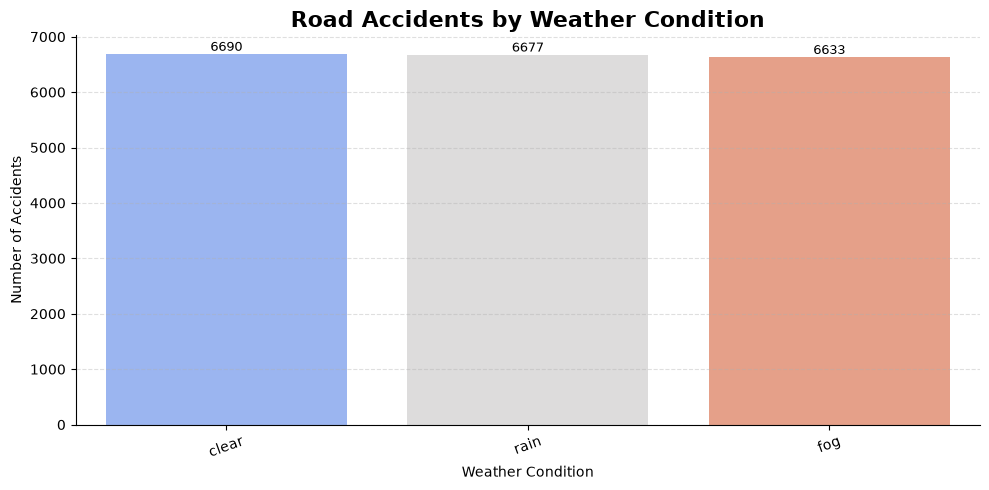

In [6]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=weather_accidents,
    x="weather",
    y="Accidents",
    hue="weather",
    palette="coolwarm",
    legend=False
)

plt.title(
    "Road Accidents by Weather Condition",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=20)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=9
    )

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- Accident frequency differs across weather conditions.
- Certain weather conditions are associated with a noticeably higher number of accidents.
- Adverse weather may contribute to reduced road safety. -->

### Business Insight
Weather-based accident analysis helps authorities issue travel advisories, improve road maintenance during adverse weather, and strengthen traffic management strategies.

## Analysis 2
### Business Question
Which road types are most accident-prone?

In [7]:
road_accidents=df.groupby("road_type").size().sort_values(ascending=False).reset_index(name="Accidents")
road_accidents

,road_type,Accidents
0,urban,6745
1,rural,6639
2,highway,6616


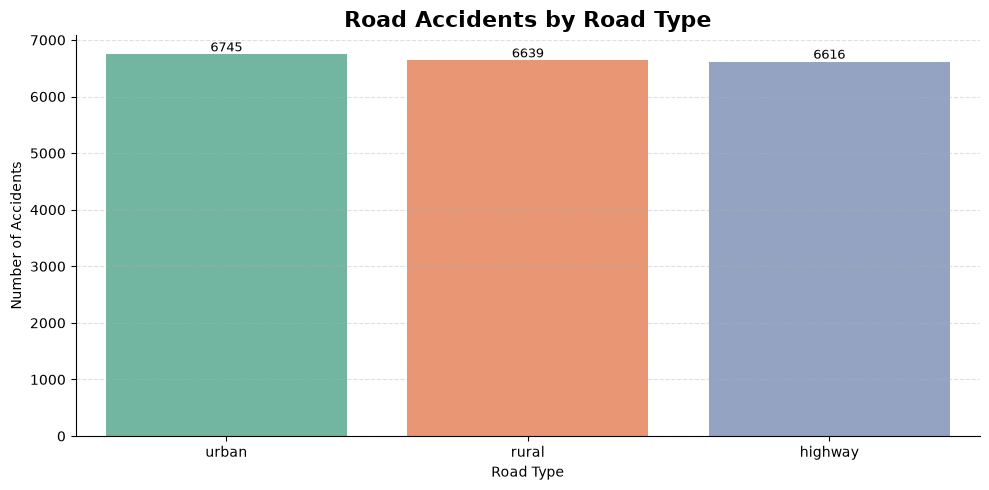

In [8]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=road_accidents,
    x="road_type",
    y="Accidents",
    hue="road_type",
    palette="Set2",
    legend=False
)

plt.title(
    "Road Accidents by Road Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Road Type")
plt.ylabel("Number of Accidents")

plt.grid(axis="y", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=9
    )

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- Accident frequency differs across road types.
- Certain road types consistently report more accidents.
- Road design and traffic flow may influence accident occurrence. -->

### Business Insight
Road types with higher accident frequencies should be prioritized for infrastructure improvements, better signage, and stricter traffic monitoring.

## Analysis 3
### Business Question
Does traffic density influence accident severity?

In [9]:
traffic_severity=df.groupby("traffic_density")["casualties"].mean().sort_values(ascending=False).reset_index()
traffic_severity

,traffic_density,casualties
0,high,1.732585
1,medium,1.726394
2,low,1.720391


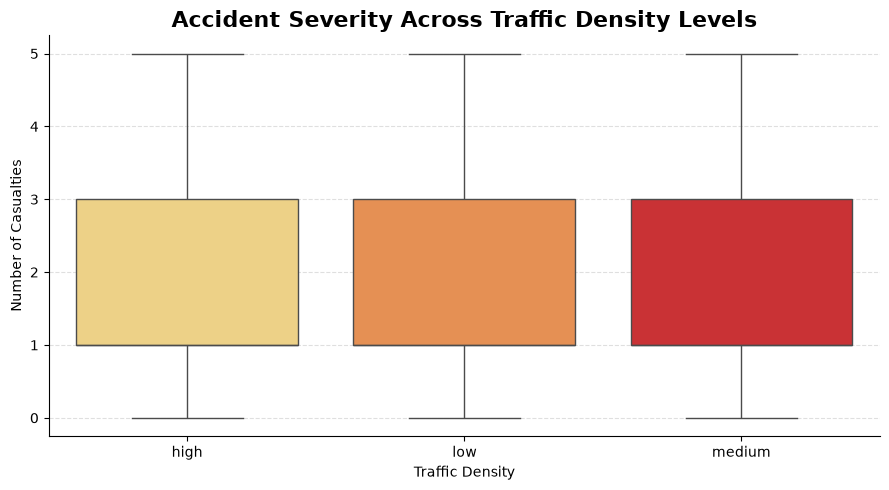

In [10]:
plt.figure(figsize=(9,5))

ax = sns.boxplot(
    data=df,
    x="traffic_density",
    y="casualties",
    hue="traffic_density",
    palette="YlOrRd",
    legend=False
)

plt.title(
    "Accident Severity Across Traffic Density Levels",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Traffic Density")
plt.ylabel("Number of Casualties")

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- Casualty levels vary across different traffic density categories.
- Some traffic density levels show greater variability in accident severity.
- High traffic density may contribute to more severe accidents.

### Business Insight

Understanding how traffic density affects accident severity helps traffic authorities improve congestion management and reduce the impact of severe accidents. 

## Analysis 4
### Business Question
Do traffic signals influence accident severity?

In [11]:
signal_severity = pd.crosstab(
    df["traffic_signal"],
    df["accident_severity"])
signal_severity

accident_severity,fatal,major,minor
traffic_signal,,,
0,1516,3016,5471
1,1471,2972,5554


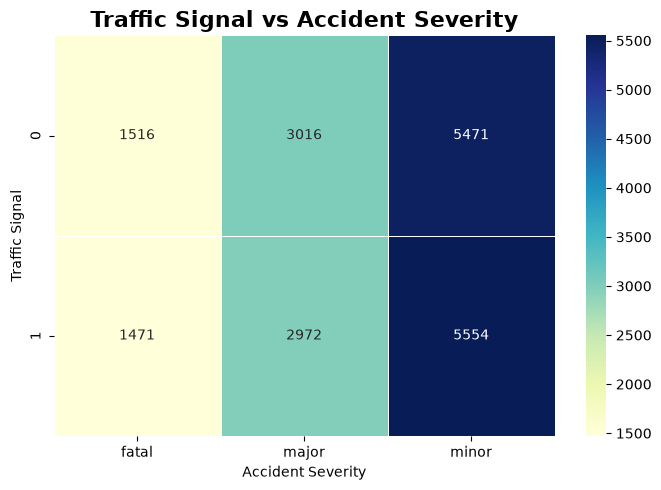

In [12]:
plt.figure(figsize=(7,5))

sns.heatmap(
    signal_severity,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Traffic Signal vs Accident Severity",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Accident Severity")
plt.ylabel("Traffic Signal")

plt.tight_layout()

plt.show()

### Observation
- Accident severity differs depending on the presence of traffic signals.
- Some severity levels occur more frequently where traffic signals are absent.
- The heatmap clearly highlights the distribution of accidents across different conditions.

### Business Insight
Installing and maintaining traffic signals at critical intersections can help improve traffic regulation and reduce severe accidents.

## Analysis 5
### Business Question
What are the most common causes of road accidents?

In [13]:
cause_accidents = (df.groupby("cause").size().sort_values(ascending=False).reset_index(name="Accidents"))
cause_accidents

,cause,Accidents
0,distraction,4026
1,overspeeding,4025
2,weather,3997
3,drunk driving,3978
4,poor road,3974


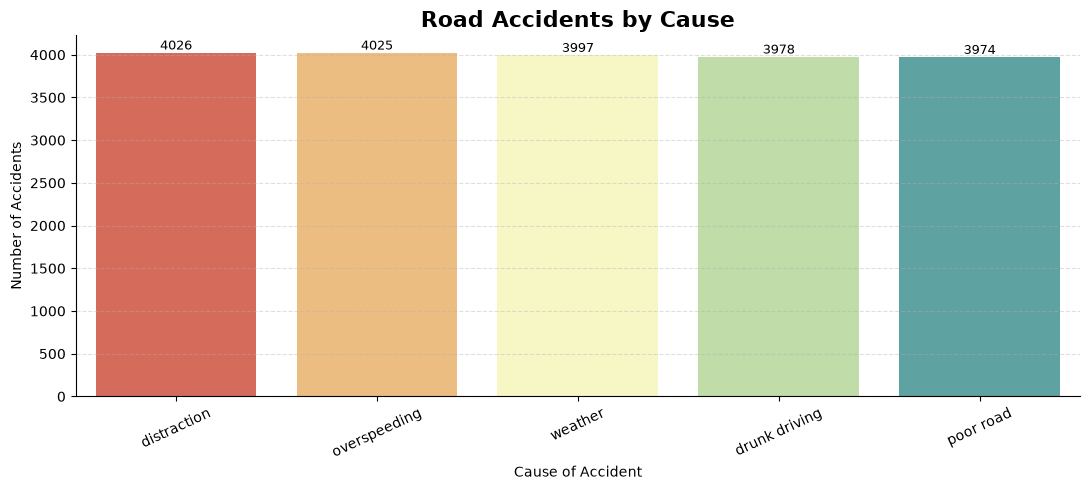

In [14]:
plt.figure(figsize=(11,5))

ax = sns.barplot(
    data=cause_accidents,
    x="cause",
    y="Accidents",
    hue="cause",
    palette="Spectral",
    legend=False
)

plt.title(
    "Road Accidents by Cause",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Cause of Accident")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=25)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=9
    )

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- Accident causes are not evenly distributed.
- Certain causes contribute to a much larger number of accidents.
- Human and environmental factors both influence accident occurrence.

### Business Insight
Understanding the leading causes of road accidents enables policymakers to design targeted awareness campaigns, strengthen law enforcement, and improve road safety regulations.

This notebook explored the environmental and operational factors affecting road accidents.

Key findings include:

- Compared accident frequency across different weather conditions.
- Identified road types associated with higher accident counts.
- Examined the relationship between traffic density and accident severity.
- Analyzed the impact of traffic signals on accident severity.
- Identified the most common causes of road accidents.

# Business Conclusion -->
Environmental and operational factors play a significant role in road accident occurrence and severity. Weather conditions, road types, traffic density, traffic signals, and accident causes all influence road safety outcomes.
These findings can support evidence-based decisions related to infrastructure planning, traffic regulation, congestion management, and public safety awareness programs.